Titanic dataset

In [1]:

import pandas as pd

data_frame = pd.read_csv("../datasets/raw/titanic/train.csv")

print("\nFirst 5 rows of the Titanic dataset:\n")
display(data_frame.head())

print("\nShape of the Titanic dataset:\n")
print(data_frame.shape)

print("\nColumns of the Titanic dataset:\n")
print(data_frame.columns)

print("\nData types of the Titanic dataset:\n")
print(data_frame.dtypes)



First 5 rows of the Titanic dataset:



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Shape of the Titanic dataset:

(891, 12)

Columns of the Titanic dataset:

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Data types of the Titanic dataset:

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [2]:
# Information about the Titanic dataset
print(data_frame.info())
print("\nNumber of Missing values in the Titanic dataset:\n")
display(data_frame.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Number of Missing values in the Titanic dataset:



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
# Percentage of missing values in the Titanic dataset
print("\nPercentage of Missing values in the Titanic dataset:\n")
display(data_frame.isnull().mean()*100)


Percentage of Missing values in the Titanic dataset:



PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [4]:
# Mean and median values of the 'Age' column in the Titanic dataset

print("\nAge mean value:")
print(data_frame['Age'].mean())

print("\nAge median value:")
print(data_frame['Age'].median())


Age mean value:
29.69911764705882

Age median value:
28.0


In [5]:
# Describe the 'Age' column in the Titanic dataset
data_frame['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: >

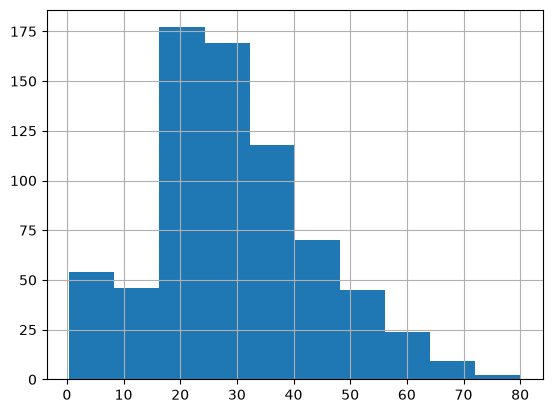

In [6]:
# Histogram of the 'Age' column in the Titanic dataset
data_frame['Age'].hist()

In [7]:
# DataFrame after filling missing values in the 'Age' column with the median value
processed_data= data_frame.copy()
processed_data['Age']=processed_data['Age'].fillna(processed_data['Age'].median())
processed_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
#Verifying the mode of the 'Embarked' column in the Titanic dataset
processed_data['Embarked'].mode()[0]

'S'

In [9]:
# Filling missing values in the 'Embarked' column with the mode value
processed_data['Embarked']=processed_data['Embarked'].fillna(processed_data['Embarked'].mode()[0])
processed_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [10]:
#Cabin column Investigation

# Checking the number of unique values in the 'Cabin' column
print("\nFirst 15 non-null values of the 'Cabin' column in the Titanic dataset:\n")
display(processed_data['Cabin'].dropna().head(15))

print("\nFrequency of Deck values in the 'Cabin' column:\n")
print(processed_data['Cabin'].dropna().str[0].value_counts())


First 15 non-null values of the 'Cabin' column in the Titanic dataset:



1             C85
3            C123
6             E46
10             G6
11           C103
21            D56
23             A6
27    C23 C25 C27
31            B78
52            D33
54            B30
55            C52
61            B28
62            C83
66            F33
Name: Cabin, dtype: str


Frequency of Deck values in the 'Cabin' column:

Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64


In [11]:
# Creating a new 'Deck' column from the first character of the 'Cabin' column
processed_data['Deck']=processed_data['Cabin'].str[0]
processed_data[['Cabin','Deck']].head(15)

,Cabin,Deck
0,NaN,NaN
1,C85,C
2,NaN,NaN
3,C123,C
4,NaN,NaN
5,NaN,NaN
6,E46,E
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [12]:
# Creating a new 'HasCabin' column to indicate whether a passenger has a cabin or not
processed_data['HasCabin']=processed_data['Cabin'].notnull().astype(int)
processed_data[['Cabin','HasCabin']].head(15)

,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0
5,NaN,0
6,E46,1
7,NaN,0
8,NaN,0
9,NaN,0


In [13]:
# Checking the number of passengers with and without a cabin
print("\nNumber of passengers with and without a cabin:\n")
print(processed_data['HasCabin'].value_counts())

# Checking the survival rate based on whether a passenger has a cabin or not
print("\nSurvival rate based on cabin presence:\n")
print(processed_data.groupby(['HasCabin'])['Survived'].mean()*100)


Number of passengers with and without a cabin:

HasCabin
0    687
1    204
Name: count, dtype: int64

Survival rate based on cabin presence:

HasCabin
0    29.985444
1    66.666667
Name: Survived, dtype: float64


In [14]:
# Cross-tabulation of passenger class and cabin presence
pd.crosstab(
    processed_data['Pclass'],
    processed_data['HasCabin'],
    normalize='index'
    )*100

HasCabin,0,1
Pclass,,
1,18.518519,81.481481
2,91.304348,8.695652
3,97.556008,2.443992


In [15]:
# Survival rate based on passenger class and cabin presence
processed_data.groupby(['Pclass','HasCabin'])['Survived'].mean()*100

Pclass  HasCabin
1       0           47.500000
        1           66.477273
2       0           44.047619
        1           81.250000
3       0           23.590814
        1           50.000000
Name: Survived, dtype: float64

In [16]:
# Creating a DataFrame to show survival rate based on passenger class and cabin presence
survival_by_cabin_class = (
    processed_data
    .groupby(['Pclass','HasCabin'])['Survived']
    .mean()
    .reset_index()
    )
survival_by_cabin_class['SurvivalRate']= survival_by_cabin_class['Survived']*100

survival_by_cabin_class

,Pclass,HasCabin,Survived,SurvivalRate
0,1,0,0.475000,47.500000
1,1,1,0.664773,66.477273
2,2,0,0.440476,44.047619
3,2,1,0.812500,81.250000
4,3,0,0.235908,23.590814
5,3,1,0.500000,50.000000


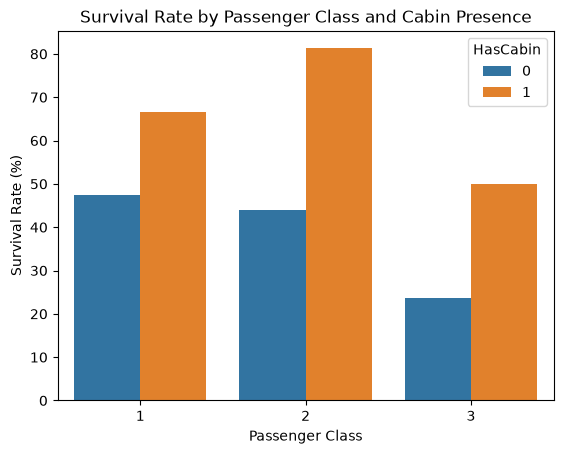

In [17]:
# Visualizing the survival rate based on passenger class and cabin presence using a bar plot

import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(
    data= survival_by_cabin_class,
    x='Pclass',
    y='SurvivalRate',
    hue='HasCabin',
    errorbar=None
)

plt.title('Survival Rate by Passenger Class and Cabin Presence')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')

plt.show()

In [18]:
print("\nFrequency of Deck values in the 'Cabin' column:\n")
print(processed_data['Deck'].value_counts())

print("\nSurvival rate based on Deck:\n")
print(processed_data.groupby('Deck')['Survived'].mean()*100)


Frequency of Deck values in the 'Cabin' column:

Deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

Survival rate based on Deck:

Deck
A    46.666667
B    74.468085
C    59.322034
D    75.757576
E    75.000000
F    61.538462
G    50.000000
T     0.000000
Name: Survived, dtype: float64


In [19]:
# Creating a DataFrame to show survival rate based on Deck
deck_summary = (
    processed_data
    .groupby('Deck')['Survived']
    .agg(['count','mean'])
)

deck_summary

,count,mean
Deck,,
A,15,0.466667
B,47,0.744681
C,59,0.593220
D,33,0.757576
E,32,0.750000
F,13,0.615385
G,4,0.500000
T,1,0.000000


In [20]:
# Calculate survival rate based on Deck and rename the 'count' column to 'PassengerCount'

deck_summary['SurvivalRate'] = deck_summary['mean']*100
deck_summary = deck_summary.rename(
    columns={'count': 'PassengerCount'}
)

deck_summary

,PassengerCount,mean,SurvivalRate
Deck,,,
A,15,0.466667,46.666667
B,47,0.744681,74.468085
C,59,0.593220,59.322034
D,33,0.757576,75.757576
E,32,0.750000,75.000000
F,13,0.615385,61.538462
G,4,0.500000,50.000000
T,1,0.000000,0.000000


In [21]:

# Deleting the 'mean' column and resetting the index of the deck_summary DataFrame

deck_summary = deck_summary.drop(columns=['mean']).reset_index()
deck_summary

,Deck,PassengerCount,SurvivalRate
0,A,15,46.666667
1,B,47,74.468085
2,C,59,59.322034
3,D,33,75.757576
4,E,32,75.000000
5,F,13,61.538462
6,G,4,50.000000
7,T,1,0.000000


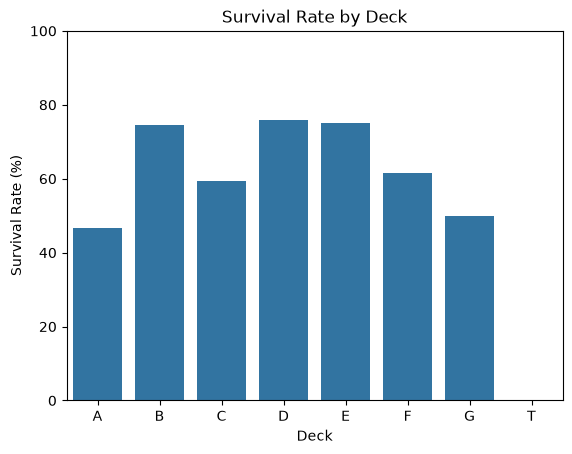

In [22]:
# Visualizing the survival rate based on Deck using a bar plot
sns.barplot(
    data=deck_summary,
    x='Deck',
    y='SurvivalRate',
    errorbar=None
)

plt.title('Survival Rate by Deck')
plt.xlabel('Deck')
plt.ylabel('Survival Rate (%)')
plt.ylim(0,100)

plt.show()

In [23]:
processed_data['Deck']=processed_data['Deck'].fillna('Unknown')
print(processed_data['Deck'].value_counts())

print("\nNumber of Missing values in the 'Deck' column after filling missing values:\n")
print(processed_data['Deck'].isnull().sum())

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

Number of Missing values in the 'Deck' column after filling missing values:

0


In [24]:
# Calculating the survival rate for each deck
processed_data.groupby(['Deck'])['Survived'].mean()*100

Deck
A          46.666667
B          74.468085
C          59.322034
D          75.757576
E          75.000000
F          61.538462
G          50.000000
T           0.000000
Unknown    29.985444
Name: Survived, dtype: float64

In [25]:
print("\nNumber of duplicate rows in the Titanic dataset:\n")
print(processed_data.duplicated().sum())

print("\nData types of the processed Titanic dataset:")
processed_data.dtypes


Number of duplicate rows in the Titanic dataset:

0

Data types of the processed Titanic dataset:


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
Deck               str
HasCabin         int64
dtype: object

In [26]:
processed_data['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

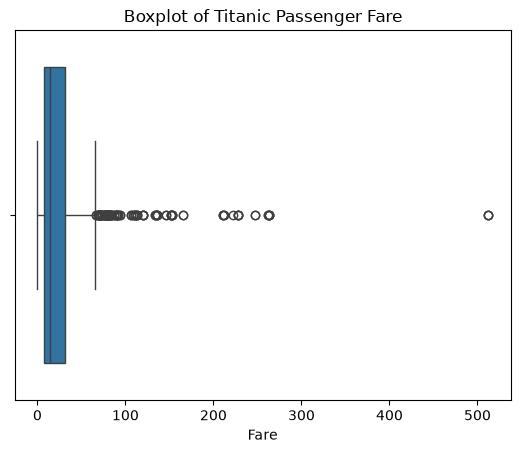

In [27]:
# Visualizing the distribution of the 'Fare' column using a boxplot
sns.boxplot(x=processed_data['Fare'])

plt.title('Boxplot of Titanic Passenger Fare')
plt.xlabel('Fare')

plt.show()

In [28]:
# Calculating the first quartile (Q1), third quartile (Q3), and interquartile range (IQR) for the 'Fare' column
Q1= processed_data['Fare'].quantile(0.25)
Q3= processed_data['Fare'].quantile(0.75)

IRQ= Q3-Q1

lower_bound= Q1-1.5*IRQ
upper_bound= Q3+1.5*IRQ

print("Q1:", Q1)
print("Q3:", Q3)
print("IRQ:", IRQ)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 7.9104
Q3: 31.0
IRQ: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344


In [29]:
# Identifying fare outliers in the processed Titanic dataset
fare_outliers= processed_data[processed_data['Fare']>upper_bound]
print("The number of fare outliers:",fare_outliers.shape[0])

The number of fare outliers: 116


In [30]:
fare_outliers[['PassengerId','Pclass','Fare','Ticket','Cabin','Survived']].sort_values(by='Fare',ascending=False).head(15)

,PassengerId,Pclass,Fare,Ticket,Cabin,Survived
258,259,1,512.3292,PC 17755,NaN,1
737,738,1,512.3292,PC 17755,B101,1
679,680,1,512.3292,PC 17755,B51 B53 B55,1
27,28,1,263.0000,19950,C23 C25 C27,0
341,342,1,263.0000,19950,C23 C25 C27,1
438,439,1,263.0000,19950,C23 C25 C27,0
88,89,1,263.0000,19950,C23 C25 C27,1
311,312,1,262.3750,PC 17608,B57 B59 B63 B66,1
742,743,1,262.3750,PC 17608,B57 B59 B63 B66,1
299,300,1,247.5208,PC 17558,B58 B60,1


In [31]:
processed_data.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


In [32]:
# Log transformation of the 'Fare' column to reduce skewness
# and lessen the influence of large values

import numpy as np

processed_data['FareLog'] = np.log1p(processed_data['Fare'])

processed_data[['Fare', 'FareLog']].head(10)

,Fare,FareLog
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765
5,8.4583,2.246893
6,51.8625,3.967694
7,21.0750,3.094446
8,11.1333,2.495954
9,30.0708,3.436268


In [33]:
# Descriptive statistics of the 'Fare' and 'FareLog' columns in the processed Titanic dataset
processed_data[['Fare', 'FareLog']].describe()

,Fare,FareLog
count,891.000000,891.000000
mean,32.204208,2.962246
std,49.693429,0.969048
min,0.000000,0.000000
25%,7.910400,2.187218
50%,14.454200,2.737881
75%,31.000000,3.465736
max,512.329200,6.240917


In [34]:
# Checking the skewness of the 'Fare' and 'FareLog' columns in the processed Titanic dataset

#skew ≈ 0    → roughly symmetric
#skew > 0    → right-skewed
#skew < 0    → left-skewed

processed_data[['Fare', 'FareLog']].skew()

Fare       4.787317
FareLog    0.394928
dtype: float64

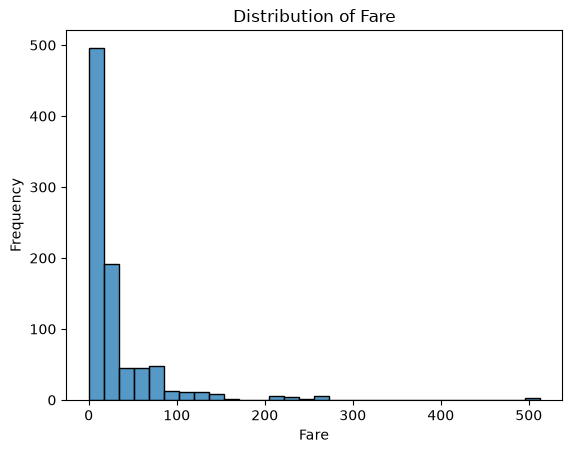

In [35]:
sns.histplot(processed_data['Fare'], bins=30)

plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

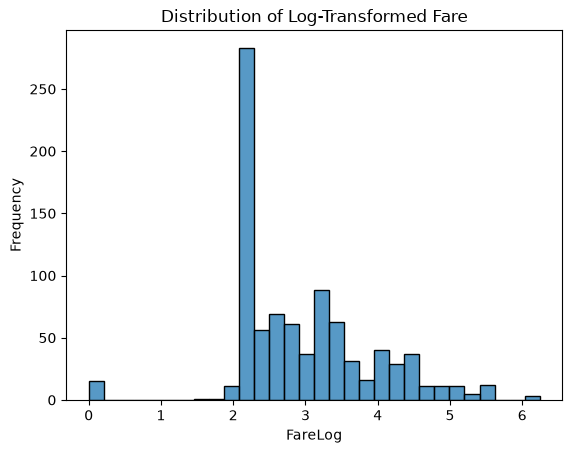

In [36]:
sns.histplot(processed_data['FareLog'], bins=30)

plt.title('Distribution of Log-Transformed Fare')
plt.xlabel('FareLog')
plt.ylabel('Frequency')

plt.show()

In [37]:
processed_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [38]:
# Encoding the 'Sex' column in the processed Titanic dataset using a mapping of 'female' to 0 and 'male' to 1 
processed_data['SexEncoded'] = processed_data['Sex'].map({
    'female' : 0,
    'male' : 1
})

display(processed_data[['Sex','SexEncoded']].head(10))
processed_data['SexEncoded'].value_counts()

,Sex,SexEncoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1
5,male,1
6,male,1
7,male,1
8,female,0
9,female,0


SexEncoded
1    577
0    314
Name: count, dtype: int64

In [39]:
# Encoding the 'Embarked' column in the processed Titanic dataset using one-hot encoding

embarked_encoded = pd.get_dummies(
    processed_data['Embarked'],
    prefix='Embarked',
    dtype=int
)

embarked_encoded.head(10)

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
5,0,1,0
6,0,0,1
7,0,0,1
8,0,0,1
9,1,0,0


In [40]:
processed_data_encoded = pd.concat(
    [processed_data, embarked_encoded],
    axis=1
)

processed_data_encoded[['Embarked','Embarked_C','Embarked_Q','Embarked_S']].head(10)

,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,S,0,0,1
1,C,1,0,0
2,S,0,0,1
3,S,0,0,1
4,S,0,0,1
5,Q,0,1,0
6,S,0,0,1
7,S,0,0,1
8,S,0,0,1
9,C,1,0,0


In [41]:
processed_data_encoded = processed_data_encoded.drop(columns=['Embarked'])
processed_data_encoded.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Deck', 'HasCabin', 'FareLog',
       'SexEncoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')

In [42]:
# One-Hot Encoding the 'Deck' column to convert categorical deck values
# into separate numeric columns for machine learning
deck_encoded= pd.get_dummies(
    processed_data_encoded['Deck'],
    prefix='Deck',
    dtype= int
)

deck_encoded.head(10)

,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,0,0,0,0,0,0,0,1
1,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1
3,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,1
6,0,0,0,0,1,0,0,0,0
7,0,0,0,0,0,0,0,0,1
8,0,0,0,0,0,0,0,0,1
9,0,0,0,0,0,0,0,0,1


In [43]:
# Adding the One-Hot Encoded 'Deck' columns to the processed dataset
# and previewing them alongside the original 'Deck' column
processed_data_encoded = pd.concat(
    [processed_data_encoded, deck_encoded],
    axis=1
)

processed_data_encoded[
    ['Deck', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D',
     'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']
].head(10)

,Deck,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,Unknown,0,0,0,0,0,0,0,0,1
1,C,0,0,1,0,0,0,0,0,0
2,Unknown,0,0,0,0,0,0,0,0,1
3,C,0,0,1,0,0,0,0,0,0
4,Unknown,0,0,0,0,0,0,0,0,1
5,Unknown,0,0,0,0,0,0,0,0,1
6,E,0,0,0,0,1,0,0,0,0
7,Unknown,0,0,0,0,0,0,0,0,1
8,Unknown,0,0,0,0,0,0,0,0,1
9,Unknown,0,0,0,0,0,0,0,0,1


In [44]:
# Removing the original 'Deck' column after One-Hot Encoding
processed_data_encoded = processed_data_encoded.drop(columns=['Deck'])

processed_data_encoded.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'HasCabin', 'FareLog', 'SexEncoded',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Deck_A', 'Deck_B', 'Deck_C',
       'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown'],
      dtype='str')

In [45]:
# Checking the remaining text columns in the encoded dataset
processed_data_encoded.select_dtypes(include='str').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin'], dtype='str')

In [46]:
# Removing raw 'Sex' and 'Cabin' columns after creating their encoded/engineered features
processed_data_encoded = processed_data_encoded.drop(
    columns=['Sex','Cabin']
)

processed_data_encoded.select_dtypes(include='str').columns

Index(['Name', 'Ticket'], dtype='str')

In [47]:
# Inspecting passenger names to identify useful patterns for feature engineering
processed_data_encoded['Name'].head(15)

0                               Braund, Mr. Owen Harris
1     Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                Heikkinen, Miss. Laina
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                              Allen, Mr. William Henry
5                                      Moran, Mr. James
6                               McCarthy, Mr. Timothy J
7                        Palsson, Master. Gosta Leonard
8     Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                   Nasser, Mrs. Nicholas (Adele Achem)
10                      Sandstrom, Miss. Marguerite Rut
11                             Bonnell, Miss. Elizabeth
12                       Saundercock, Mr. William Henry
13                          Andersson, Mr. Anders Johan
14                 Vestrom, Miss. Hulda Amanda Adolfina
Name: Name, dtype: str

In [48]:
# Format:  Surname, Title. Rest of Name
# Inspecting the part of each passenger name that contains the title
processed_data_encoded['Name'].str.split(',').str[1].head(15)

0                                 Mr. Owen Harris
1      Mrs. John Bradley (Florence Briggs Thayer)
2                                     Miss. Laina
3              Mrs. Jacques Heath (Lily May Peel)
4                               Mr. William Henry
5                                       Mr. James
6                                   Mr. Timothy J
7                           Master. Gosta Leonard
8        Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                     Mrs. Nicholas (Adele Achem)
10                           Miss. Marguerite Rut
11                                Miss. Elizabeth
12                              Mr. William Henry
13                               Mr. Anders Johan
14                    Miss. Hulda Amanda Adolfina
Name: Name, dtype: object

In [49]:
# Extracting passenger titles from the 'Name' column
processed_data_encoded['Title']=(
    processed_data_encoded['Name']
    .str.split(',')
    .str[1]
    .str.split('.')
    .str[0]
    .str.strip()
)

processed_data_encoded[['Name','Title']].head(15)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [50]:
# Checking the frequency of passenger titles
processed_data_encoded['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [51]:
# Summarizing passenger count and survival rate for each passenger title
title_summary = (
    processed_data_encoded
    .groupby('Title')['Survived']
    .agg(['count','mean'])
    .sort_values('count',ascending= False)
)

title_summary['SurvivalRate']= title_summary['mean']*100

title_summary

,count,mean,SurvivalRate
Title,,,
Mr,517,0.156673,15.667311
Miss,182,0.697802,69.780220
Mrs,125,0.792000,79.200000
Master,40,0.575000,57.500000
Dr,7,0.428571,42.857143
Rev,6,0.000000,0.000000
Mlle,2,1.000000,100.000000
Major,2,0.500000,50.000000
Col,2,0.500000,50.000000


In [52]:
# Normalizing equivalent passenger titles into common categories
processed_data_encoded['Title']=processed_data_encoded['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

processed_data_encoded['Title'].value_counts()

Title
Mr              517
Miss            185
Mrs             126
Master           40
Dr                7
Rev               6
Major             2
Col               2
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [53]:
# Grouping uncommon passenger titles into a single 'Rare' category
common_titles=['Mr','Miss','Mrs','Master']

processed_data_encoded['Title']= processed_data_encoded['Title'].where(
    processed_data_encoded['Title'].isin(common_titles),
    'Rare'
)

processed_data_encoded['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [54]:
# One-Hot Encoding the cleaned 'Title' categories
title_encoded= pd.get_dummies(
    processed_data_encoded['Title'],
    prefix='Title',
    dtype= int
)

title_encoded.head(10)

,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,0,1,0,0
1,0,0,0,1,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,1,0,0
5,0,0,1,0,0
6,0,0,1,0,0
7,1,0,0,0,0
8,0,0,0,1,0
9,0,0,0,1,0


In [55]:
# Adding the One-Hot Encoded 'Title' columns to the processed dataset
processed_data_encoded = pd.concat(
    [processed_data_encoded, title_encoded],
    axis=1
)

processed_data_encoded[
    ['Title', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
].head(10)

,Title,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,Mr,0,0,1,0,0
1,Mrs,0,0,0,1,0
2,Miss,0,1,0,0,0
3,Mrs,0,0,0,1,0
4,Mr,0,0,1,0,0
5,Mr,0,0,1,0,0
6,Mr,0,0,1,0,0
7,Master,1,0,0,0,0
8,Mrs,0,0,0,1,0
9,Mrs,0,0,0,1,0


In [56]:
# Removing the original 'Name' and 'Title' columns after extracting and encoding titles
processed_data_encoded = processed_data_encoded.drop(
    columns=['Name', 'Title']
)

processed_data_encoded.select_dtypes(include='str').columns

Index(['Ticket'], dtype='str')

In [57]:
# Inspecting ticket frequency to identify repeated or shared tickets
processed_data_encoded['Ticket'].value_counts().head(15)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
19950           4
W./C. 6608      4
4133            4
LINE            4
113781          4
Name: count, dtype: int64

In [58]:
# Creating 'TicketGroupSize' from the number of passengers sharing each ticket
processed_data_encoded['TicketGroupSize'] = (
    processed_data_encoded.groupby('Ticket')['Ticket'].transform('count')
)

processed_data_encoded[['Ticket','TicketGroupSize']].head(15)

,Ticket,TicketGroupSize
0,A/5 21171,1
1,PC 17599,1
2,STON/O2. 3101282,1
3,113803,2
4,373450,1
5,330877,1
6,17463,1
7,349909,4
8,347742,3
9,237736,2


In [59]:
# Checking the distribution of passenger group sizes based on shared tickets
processed_data_encoded['TicketGroupSize'].value_counts().sort_index()

TicketGroupSize
1    547
2    188
3     63
4     44
5     10
6     18
7     21
Name: count, dtype: int64

In [60]:
# Checking survival rate by ticket group size
processed_data_encoded.groupby('TicketGroupSize')['Survived'].mean()*100

TicketGroupSize
1    29.798903
2    57.446809
3    69.841270
4    50.000000
5     0.000000
6     0.000000
7    23.809524
Name: Survived, dtype: float64

In [61]:
# Summarizing passenger count and survival rate by ticket group size
ticket_group_summary = (
    processed_data_encoded
    .groupby('TicketGroupSize')['Survived']
    .agg(['count','mean'])
)

ticket_group_summary['SurvivalRate'] = ticket_group_summary['mean']*100

ticket_group_summary

,count,mean,SurvivalRate
TicketGroupSize,,,
1,547,0.297989,29.798903
2,188,0.574468,57.446809
3,63,0.698413,69.841270
4,44,0.500000,50.000000
5,10,0.000000,0.000000
6,18,0.000000,0.000000
7,21,0.238095,23.809524


In [62]:
# Removing the raw 'Ticket' column after extracting 'TicketGroupSize'
processed_data_encoded = processed_data_encoded.drop(columns=['Ticket'])

processed_data_encoded.select_dtypes(include='str').columns

Index([], dtype='str')

In [63]:
# Checking passenger class distribution before encoding
processed_data_encoded['Pclass'].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [65]:
# One-Hot Encoding the 'Pclass' column to represent passenger classes as separate categories
pclass_encoded = pd.get_dummies(
    processed_data_encoded['Pclass'],
    prefix='Pclass',
    dtype=int
)
pclass_encoded.head(10)

,Pclass_1,Pclass_2,Pclass_3
0,0,0,1
1,1,0,0
2,0,0,1
3,1,0,0
4,0,0,1
5,0,0,1
6,1,0,0
7,0,0,1
8,0,0,1
9,0,1,0


In [66]:
# Adding the One-Hot Encoded 'Pclass' columns to the processed dataset
processed_data_encoded = pd.concat(
    [processed_data_encoded, pclass_encoded],
    axis=1
)

processed_data_encoded[
    ['Pclass','Pclass_1','Pclass_2','Pclass_3']
].head(10)

,Pclass,Pclass_1,Pclass_2,Pclass_3
0,3,0,0,1
1,1,1,0,0
2,3,0,0,1
3,1,1,0,0
4,3,0,0,1
5,3,0,0,1
6,1,1,0,0
7,3,0,0,1
8,3,0,0,1
9,2,0,1,0


In [67]:
# Removing the original 'Pclass' column after One-Hot Encoding
processed_data_encoded = processed_data_encoded.drop(columns=['Pclass'])

processed_data_encoded.columns

Index(['PassengerId', 'Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin',
       'FareLog', 'SexEncoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G',
       'Deck_T', 'Deck_Unknown', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'TicketGroupSize', 'Pclass_1', 'Pclass_2',
       'Pclass_3'],
      dtype='str')

In [68]:
# Creating 'FamilySize' from siblings/spouse, parents/children, and the passenger
processed_data_encoded['FamilySize'] = (
    processed_data_encoded['SibSp']
    + processed_data_encoded['Parch']
    + 1
)
processed_data_encoded[['SibSp','Parch','FamilySize']].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [69]:
# Checking the distribution of passenger family sizes
processed_data_encoded['FamilySize'].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [70]:
# Checking survival rate by family size
processed_data_encoded.groupby('FamilySize')['Survived'].mean()*100

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

In [71]:
# Creating an 'IsAlone' feature from 'FamilySize'
processed_data_encoded['IsAlone'] = (
    processed_data_encoded['FamilySize'] == 1
).astype(int)

processed_data_encoded[['FamilySize','IsAlone']].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [72]:
# Checking survival rate based on whether a passenger was traveling alone
processed_data_encoded.groupby('IsAlone')['Survived'].mean()*100

IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64